<a href="https://colab.research.google.com/github/asrianda/jurnal/blob/main/Pseudo_Label_Maximum_Likelihood_Baru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#- Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

**Membaca Dataset**

In [ ]:
df = pd.read_csv("dataset_25000.csv")

print(df.shape)
df.head()

(25000, 11)


,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD122395,CUS1406,B2B,Volvic,Water,0.99,16.0,0.10,14.26,Hessen,2021-07-14
1,ORD252357,CUS653,B2C,Johnnie Walker,Alcoholic Beverages,36.59,14.0,0.00,512.26,Brandenburg,2022-08-28
2,ORD302318,CUS8336,B2C,Granini Apple,Juices,1.64,5.0,0.00,8.20,Berlin,2022-12-10
3,ORD283695,CUS3285,B2B,Fritz-Kola,Soft Drinks,2.22,22.0,0.05,46.40,Hessen,2021-04-25
4,ORD242911,CUS1849,B2B,Tanqueray,Alcoholic Beverages,24.15,6.0,0.05,137.65,Hamburg,2022-01-01


**Memilih Fitur Numerik**

In [ ]:
features = [
    "Unit_Price",
    "Quantity",
    "Discount",
    "Total_Price"
]

X = df[features]

**Normalisasi Data**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Menggunakan PCA sebagai pendekatan H(θ)**
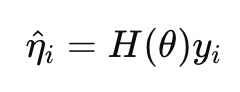


In [ ]:
pca = PCA(n_components=1)
eta_hat = pca.fit_transform(X_scaled)
eta_hat = eta_hat.flatten()
df["latent_score"] = eta_hat

**Inisialisasi Parameter Distribusi**

Karena tidak ada clustering, parameter awal dihitung dari distribusi data.

In [ ]:
median = np.median(eta_hat)

group0 = eta_hat[eta_hat <= median]
group1 = eta_hat[eta_hat > median]

mu0 = np.mean(group0)
mu1 = np.mean(group1)

sigma0 = np.var(group0)
sigma1 = np.var(group1)

pi0 = len(group0)/len(eta_hat)
pi1 = len(group1)/len(eta_hat)

**Fungsi Likelihood Gaussian**
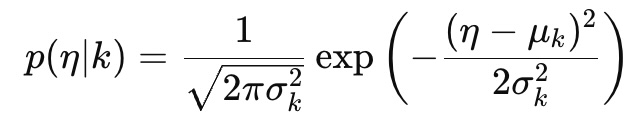

In [ ]:
def gaussian_likelihood(x, mu, sigma):

    return (1 / np.sqrt(2*np.pi*sigma)) * \
           np.exp(-(x-mu)**2 / (2*sigma))

**Fungsi Likelihood Ratio**
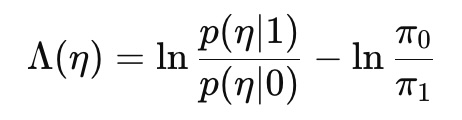

In [ ]:
def likelihood_ratio(x):

    p1 = gaussian_likelihood(x, mu1, sigma1)
    p0 = gaussian_likelihood(x, mu0, sigma0)

    return np.log(p1/p0) - np.log(pi0/pi1)

**Fungsi Kuadrat ML**

In [ ]:
A = 1/(2*sigma0) - 1/(2*sigma1)

B = mu1/(sigma1) - mu0/(sigma0)

C = np.log(np.sqrt(sigma0)/np.sqrt(sigma1)) \
    + (mu0**2)/(2*sigma0) \
    - (mu1**2)/(2*sigma1) \
    - np.log(pi0/pi1)

**Threshold Adaptif**
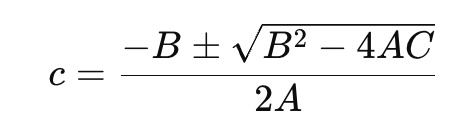

In [ ]:
if abs(A) < 1e-10:

    c = -C / B

else:

    disc = B**2 - 4*A*C
    c1 = (-B + np.sqrt(disc))/(2*A)
    c2 = (-B - np.sqrt(disc))/(2*A)

    c = np.mean([c1,c2])

print("Threshold adaptif:", c)

Threshold adaptif: -0.9358276867666024


**Generate Pseudo-Label**
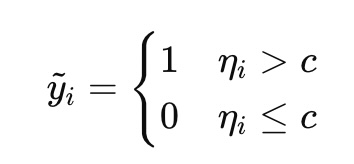

In [ ]:
pseudo_labels = []

for eta in eta_hat:

    if eta > c:
        pseudo_labels.append(1)
    else:
        pseudo_labels.append(0)

df["pseudo_label"] = pseudo_labels

**Visualisasi Decision Boundary**

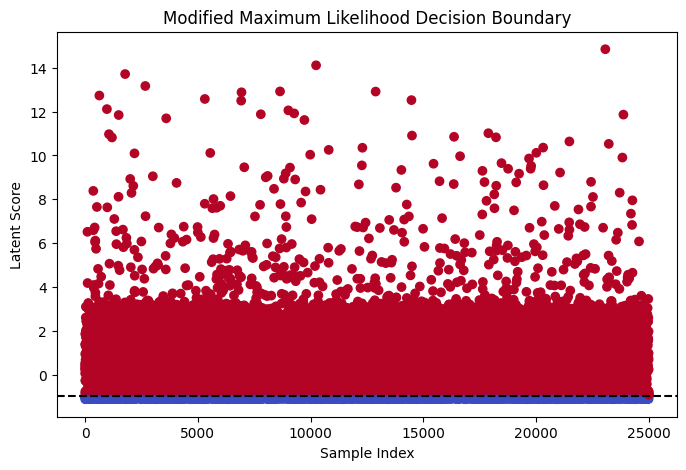

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(range(len(eta_hat)), eta_hat,
            c=df["pseudo_label"],
            cmap="coolwarm")

plt.axhline(c, color='black', linestyle='--')

plt.title("Modified Maximum Likelihood Decision Boundary")
plt.xlabel("Sample Index")
plt.ylabel("Latent Score")

plt.show()

**Simpan Dataset Baru**

In [ ]:
df.to_csv("dataset_pseudolabel_ML.csv", index=False)

print("Dataset pseudo-label berhasil disimpan")

Dataset pseudo-label berhasil disimpan


In [ ]:
df["pseudo_label"].value_counts()

,count
pseudo_label,
1,19099
0,5901


In [ ]:
print("mu0:", mu0)
print("mu1:", mu1)

print("sigma0:", sigma0)
print("sigma1:", sigma1)

print("threshold c:", c)

print("min eta:", np.min(eta_hat))
print("max eta:", np.max(eta_hat))

mu0: -0.9295126662124278
mu1: 0.9305543037155874
sigma0: 0.008072742423679629
sigma1: 2.3858704724874604
threshold c: -0.9358276867666024
min eta: -1.1023002245198135
max eta: 14.839690230338462


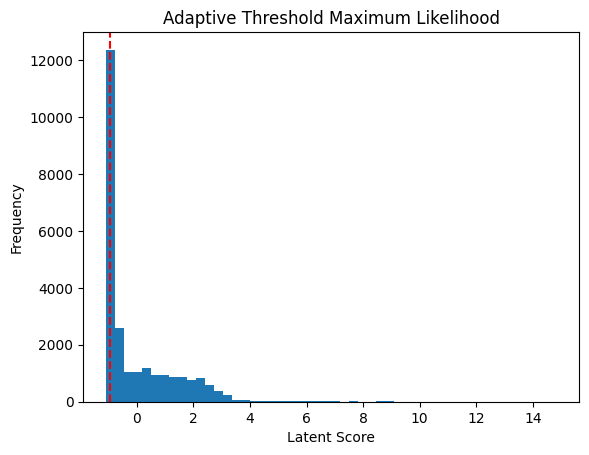

In [ ]:
plt.hist(eta_hat, bins=50)

plt.axvline(c, color='red', linestyle='--')

plt.title("Adaptive Threshold Maximum Likelihood")
plt.xlabel("Latent Score")
plt.ylabel("Frequency")

plt.show()

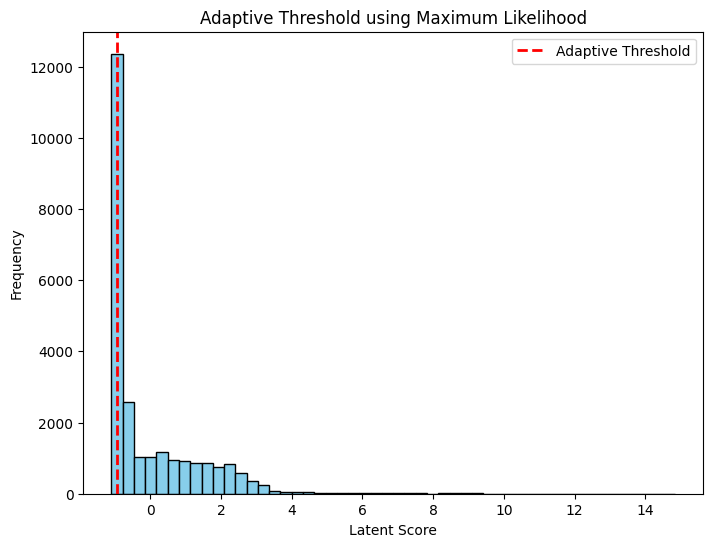

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# histogram latent score
plt.hist(eta_hat, bins=50, color='skyblue', edgecolor='black')

# threshold line
plt.axvline(c, color='red', linestyle='--', linewidth=2, label='Adaptive Threshold')

# title and labels
plt.title("Adaptive Threshold using Maximum Likelihood")
plt.xlabel("Latent Score")
plt.ylabel("Frequency")

plt.legend()

# simpan grafik
plt.savefig("latent_score_distribution.png", dpi=300, bbox_inches='tight')

# tampilkan grafik
plt.show()

**Program Analisis Dataset Pseudo-Label**

Jumlah data : (25000, 13)
    Order_ID Customer_ID Customer_Type         Product             Category  \
0  ORD122395     CUS1406           B2B          Volvic                Water   
1  ORD252357      CUS653           B2C  Johnnie Walker  Alcoholic Beverages   
2  ORD302318     CUS8336           B2C   Granini Apple               Juices   
3  ORD283695     CUS3285           B2B      Fritz-Kola          Soft Drinks   
4  ORD242911     CUS1849           B2B       Tanqueray  Alcoholic Beverages   

   Unit_Price  Quantity  Discount  Total_Price       Region  Order_Date  \
0        0.99      16.0      0.10        14.26       Hessen  2021-07-14   
1       36.59      14.0      0.00       512.26  Brandenburg  2022-08-28   
2        1.64       5.0      0.00         8.20       Berlin  2022-12-10   
3        2.22      22.0      0.05        46.40       Hessen  2021-04-25   
4       24.15       6.0      0.05       137.65      Hamburg  2022-01-01   

   latent_score  pseudo_label  
0      0.523843 

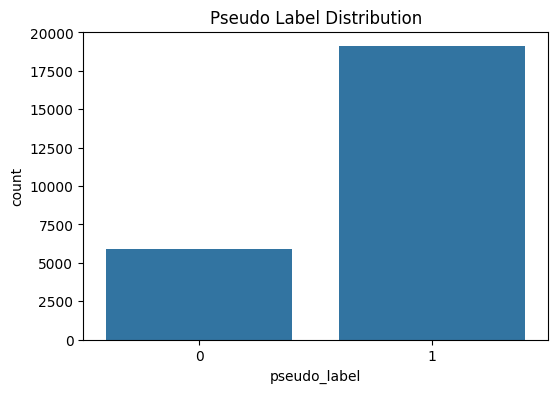


Statistik Latent Score
count    2.500000e+04
mean     3.240075e-17
std      1.435740e+00
min     -1.102300e+00
25%     -9.259798e-01
50%     -7.788217e-01
75%      6.883872e-01
max      1.483969e+01
Name: latent_score, dtype: float64


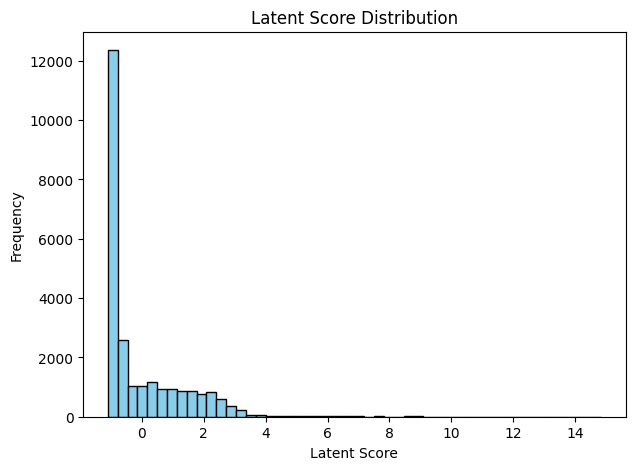

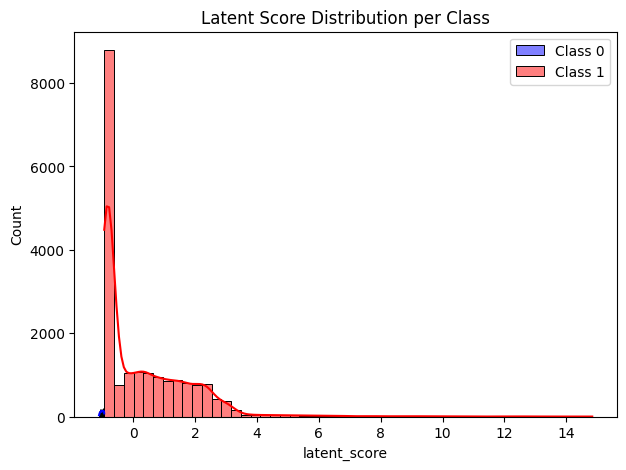


Silhouette Score : -0.2589473329707002


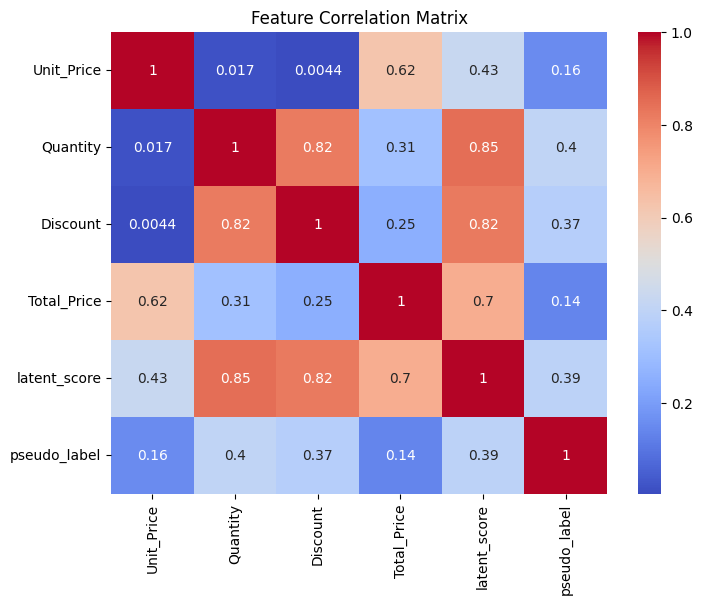


Rata-rata fitur per kelas
              Unit_Price   Quantity  Discount  Total_Price
pseudo_label                                              
0               1.661500   3.797322  0.000000     5.743865
1               7.042887  29.280957  0.039191   168.583590


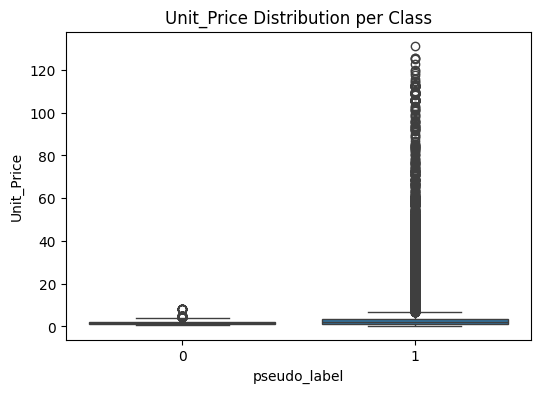

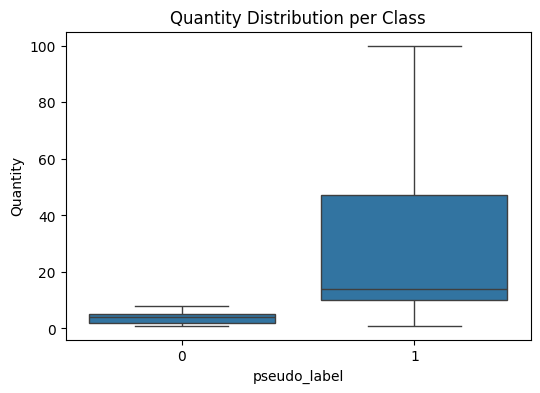

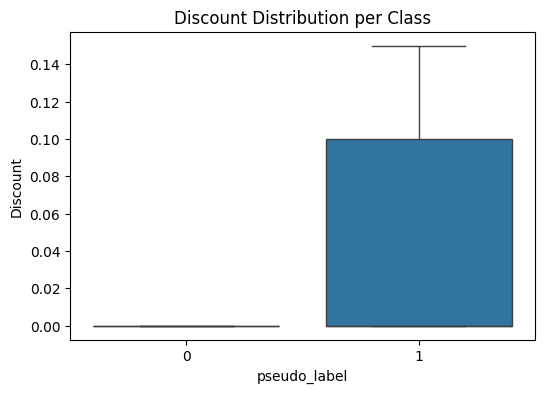

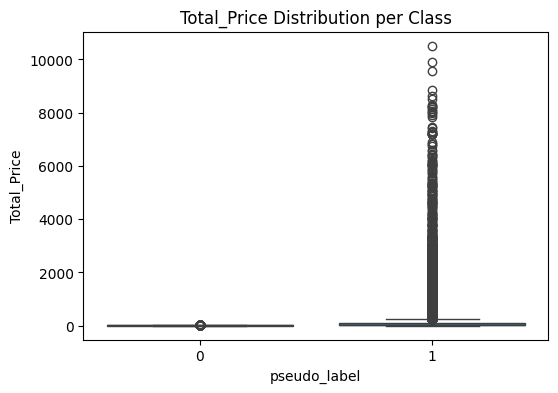

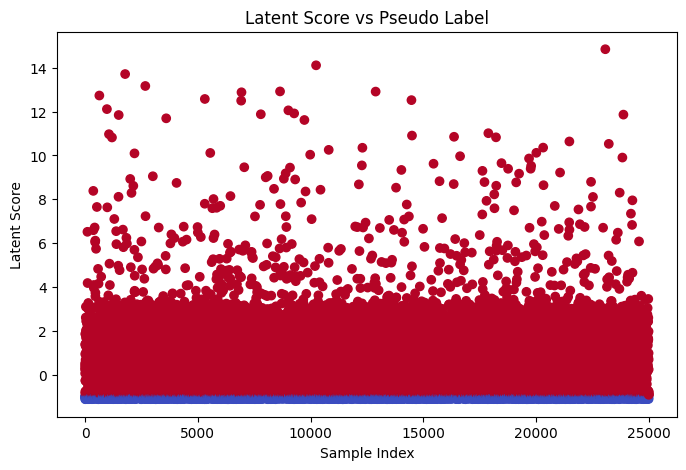


Statistik dataset disimpan


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import silhouette_score

# ==============================
# Load Dataset
# ==============================

df = pd.read_csv("dataset_pseudolabel_ML.csv")

print("Jumlah data :", df.shape)
print(df.head())

# ==============================
# 1. Distribusi Pseudo Label
# ==============================

print("\nDistribusi Pseudo Label")
print(df["pseudo_label"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="pseudo_label", data=df)
plt.title("Pseudo Label Distribution")
plt.show()

# ==============================
# 2. Statistik Latent Score
# ==============================

print("\nStatistik Latent Score")
print(df["latent_score"].describe())

# ==============================
# 3. Histogram Latent Score
# ==============================

plt.figure(figsize=(7,5))

plt.hist(df["latent_score"], bins=50, color="skyblue", edgecolor="black")

plt.title("Latent Score Distribution")
plt.xlabel("Latent Score")
plt.ylabel("Frequency")

plt.show()

# ==============================
# 4. Distribusi Latent Score per Kelas
# ==============================

plt.figure(figsize=(7,5))

sns.histplot(df[df["pseudo_label"]==0]["latent_score"],
             bins=50,
             color="blue",
             label="Class 0",
             kde=True)

sns.histplot(df[df["pseudo_label"]==1]["latent_score"],
             bins=50,
             color="red",
             label="Class 1",
             kde=True)

plt.legend()
plt.title("Latent Score Distribution per Class")
plt.show()

# ==============================
# 5. Silhouette Score
# ==============================

features = [
    "Unit_Price",
    "Quantity",
    "Discount",
    "Total_Price"
]

X = df[features]

score = silhouette_score(X, df["pseudo_label"])

print("\nSilhouette Score :", score)

# ==============================
# 6. Korelasi Fitur (HANYA NUMERIK)
# ==============================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

corr = numeric_df.corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

# ==============================
# 7. Statistik Fitur per Kelas
# ==============================

print("\nRata-rata fitur per kelas")

print(df.groupby("pseudo_label")[features].mean())

# ==============================
# 8. Boxplot per kelas
# ==============================

for col in features:

    plt.figure(figsize=(6,4))

    sns.boxplot(x="pseudo_label", y=col, data=df)

    plt.title(f"{col} Distribution per Class")

    plt.show()

# ==============================
# 9. Scatter Latent Score
# ==============================

plt.figure(figsize=(8,5))

plt.scatter(range(len(df)),
            df["latent_score"],
            c=df["pseudo_label"],
            cmap="coolwarm")

plt.title("Latent Score vs Pseudo Label")

plt.xlabel("Sample Index")
plt.ylabel("Latent Score")

plt.show()

# ==============================
# Simpan statistik
# ==============================

stats = numeric_df.describe()

stats.to_csv("dataset_statistics.csv")

print("\nStatistik dataset disimpan")

Jumlah data : (25000, 13)
    Order_ID Customer_ID Customer_Type         Product             Category  \
0  ORD122395     CUS1406           B2B          Volvic                Water   
1  ORD252357      CUS653           B2C  Johnnie Walker  Alcoholic Beverages   
2  ORD302318     CUS8336           B2C   Granini Apple               Juices   
3  ORD283695     CUS3285           B2B      Fritz-Kola          Soft Drinks   
4  ORD242911     CUS1849           B2B       Tanqueray  Alcoholic Beverages   

   Unit_Price  Quantity  Discount  Total_Price       Region  Order_Date  \
0        0.99      16.0      0.10        14.26       Hessen  2021-07-14   
1       36.59      14.0      0.00       512.26  Brandenburg  2022-08-28   
2        1.64       5.0      0.00         8.20       Berlin  2022-12-10   
3        2.22      22.0      0.05        46.40       Hessen  2021-04-25   
4       24.15       6.0      0.05       137.65      Hamburg  2022-01-01   

   latent_score  pseudo_label  
0      0.523843 

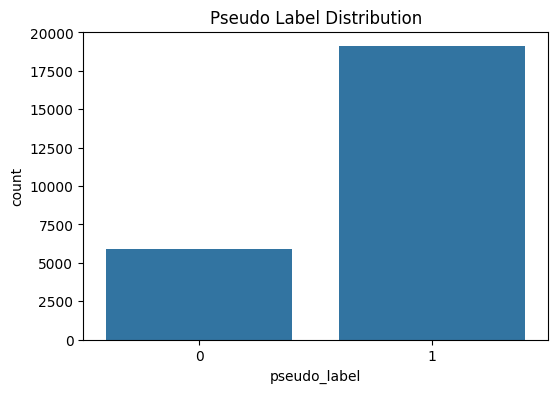


Statistik Latent Score
count    2.500000e+04
mean     3.240075e-17
std      1.435740e+00
min     -1.102300e+00
25%     -9.259798e-01
50%     -7.788217e-01
75%      6.883872e-01
max      1.483969e+01
Name: latent_score, dtype: float64


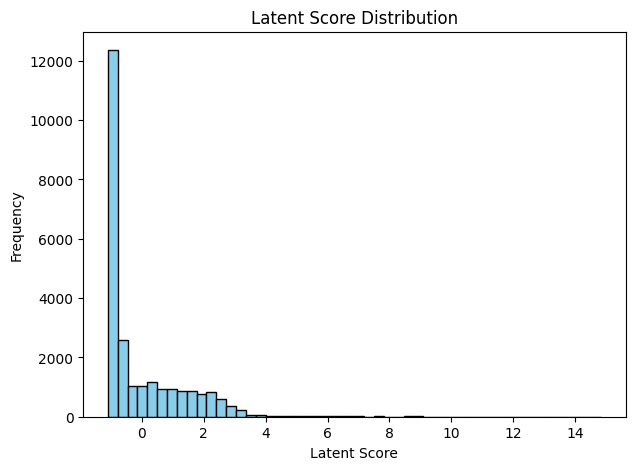

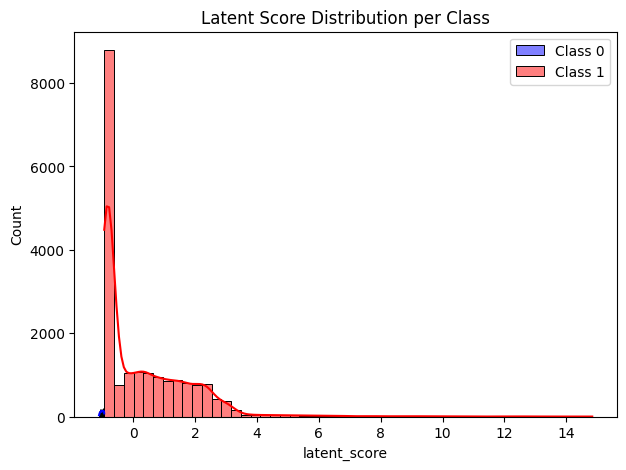


Silhouette Score : -0.2589473329707002


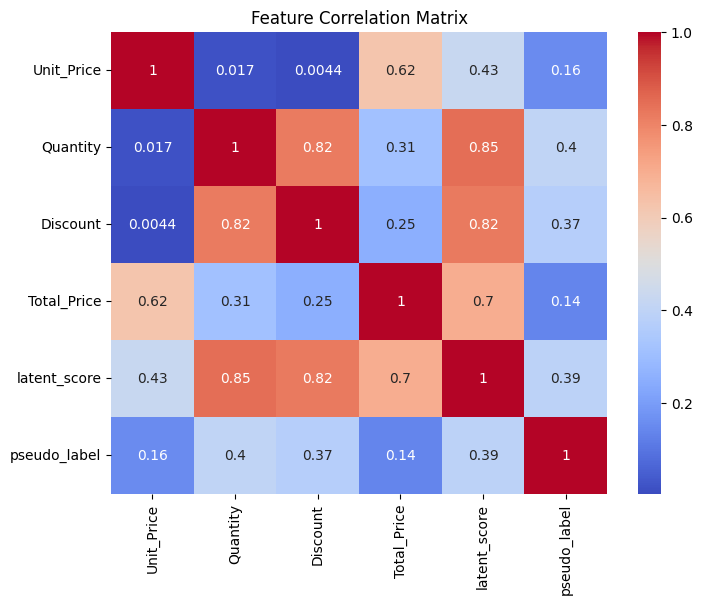


Rata-rata fitur per kelas
              Unit_Price   Quantity  Discount  Total_Price
pseudo_label                                              
0               1.661500   3.797322  0.000000     5.743865
1               7.042887  29.280957  0.039191   168.583590


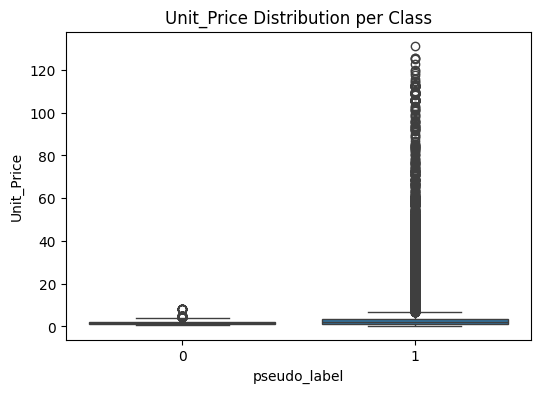

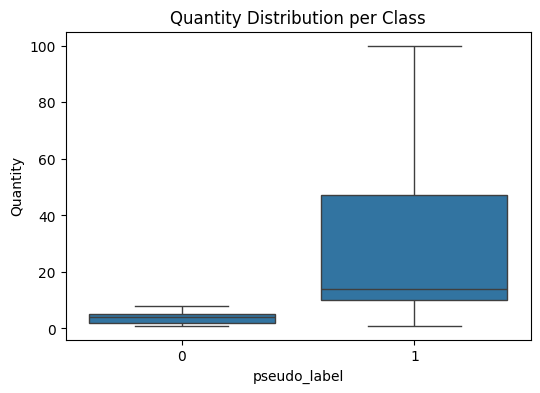

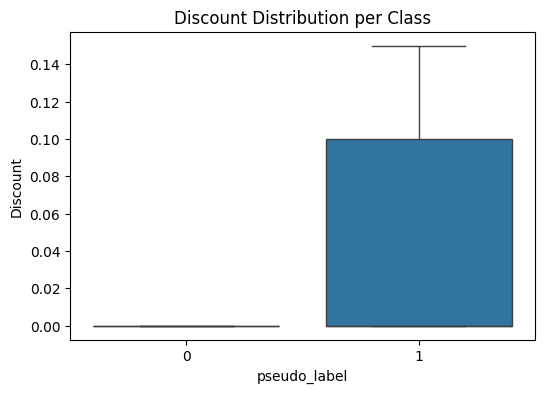

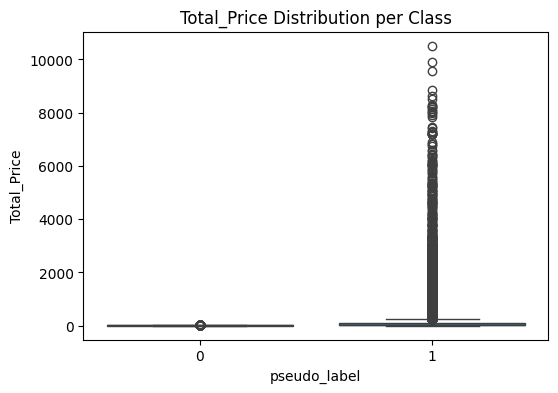

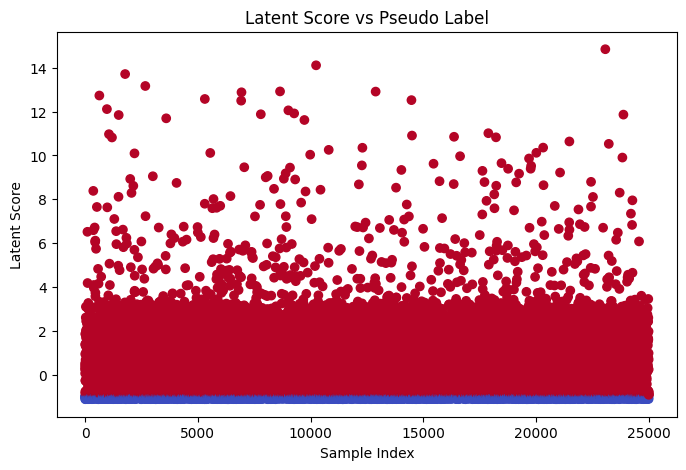


Statistik dataset disimpan


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import silhouette_score

# ==============================
# Folder untuk menyimpan grafik
# ==============================

os.makedirs("figures", exist_ok=True)

# ==============================
# Load Dataset
# ==============================

df = pd.read_csv("dataset_pseudolabel_ML.csv")

print("Jumlah data :", df.shape)
print(df.head())

# ==============================
# 1. Distribusi Pseudo Label
# ==============================

print("\nDistribusi Pseudo Label")
print(df["pseudo_label"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(x="pseudo_label", data=df)

plt.title("Pseudo Label Distribution")

plt.savefig("figures/pseudo_label_distribution.png", dpi=300, bbox_inches="tight")

plt.show()


# ==============================
# 2. Statistik Latent Score
# ==============================

print("\nStatistik Latent Score")
print(df["latent_score"].describe())


# ==============================
# 3. Histogram Latent Score
# ==============================

plt.figure(figsize=(7,5))

plt.hist(df["latent_score"], bins=50, color="skyblue", edgecolor="black")

plt.title("Latent Score Distribution")
plt.xlabel("Latent Score")
plt.ylabel("Frequency")

plt.savefig("figures/latent_score_distribution.png", dpi=300, bbox_inches="tight")

plt.show()


# ==============================
# 4. Distribusi Latent Score per Kelas
# ==============================

plt.figure(figsize=(7,5))

sns.histplot(df[df["pseudo_label"]==0]["latent_score"],
             bins=50,
             color="blue",
             label="Class 0",
             kde=True)

sns.histplot(df[df["pseudo_label"]==1]["latent_score"],
             bins=50,
             color="red",
             label="Class 1",
             kde=True)

plt.legend()

plt.title("Latent Score Distribution per Class")

plt.savefig("figures/latent_score_per_class.png", dpi=300, bbox_inches="tight")

plt.show()


# ==============================
# 5. Silhouette Score
# ==============================

features = [
    "Unit_Price",
    "Quantity",
    "Discount",
    "Total_Price"
]

X = df[features]

score = silhouette_score(X, df["pseudo_label"])

print("\nSilhouette Score :", score)


# ==============================
# 6. Korelasi Fitur (HANYA NUMERIK)
# ==============================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

corr = numeric_df.corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.savefig("figures/feature_correlation_matrix.png", dpi=300, bbox_inches="tight")

plt.show()


# ==============================
# 7. Statistik Fitur per Kelas
# ==============================

print("\nRata-rata fitur per kelas")

print(df.groupby("pseudo_label")[features].mean())


# ==============================
# 8. Boxplot per kelas
# ==============================

for col in features:

    plt.figure(figsize=(6,4))

    sns.boxplot(x="pseudo_label", y=col, data=df)

    plt.title(f"{col} Distribution per Class")

    plt.savefig(f"figures/boxplot_{col}.png", dpi=300, bbox_inches="tight")

    plt.show()


# ==============================
# 9. Scatter Latent Score
# ==============================

plt.figure(figsize=(8,5))

plt.scatter(range(len(df)),
            df["latent_score"],
            c=df["pseudo_label"],
            cmap="coolwarm")

plt.title("Latent Score vs Pseudo Label")

plt.xlabel("Sample Index")
plt.ylabel("Latent Score")

plt.savefig("figures/latent_score_scatter.png", dpi=300, bbox_inches="tight")

plt.show()


# ==============================
# Simpan statistik dataset
# ==============================

stats = numeric_df.describe()

stats.to_csv("dataset_statistics.csv")

print("\nStatistik dataset disimpan")

**loss function pseudo-label pada semi-supervised learning (Lee, 2013) dan ML**


===== PARAMETER DISTRIBUSI ML =====
mu0 : -0.9295126662124278
mu1 : 0.9305543037155874
sigma0 : 0.008072742423679629
sigma1 : 2.3858704724874604
Threshold adaptif ML: -0.9358276867666024

===== HASIL METODE LEE =====
Accuracy : 0.89828
F1 Score : 0.9309961197188831
AUC : 0.8983531736308568

Confusion Matrix
[[ 5302   599]
 [ 1944 17155]]


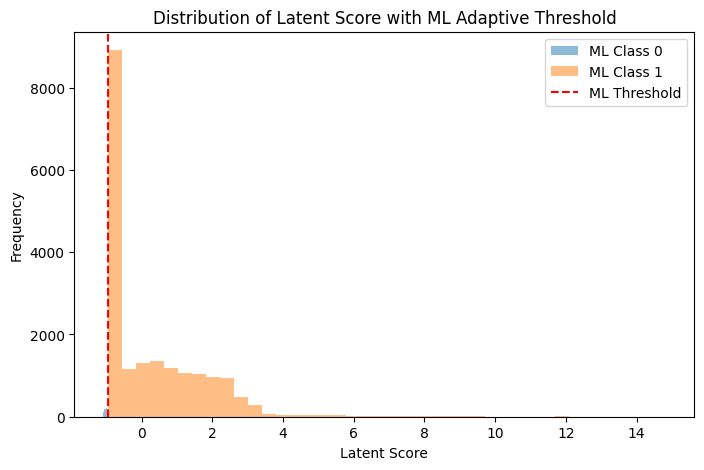

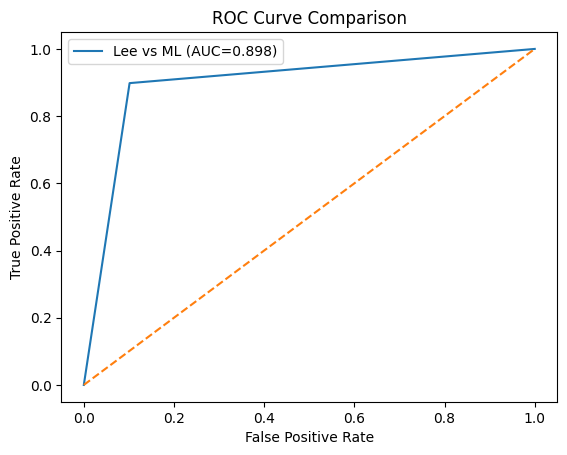

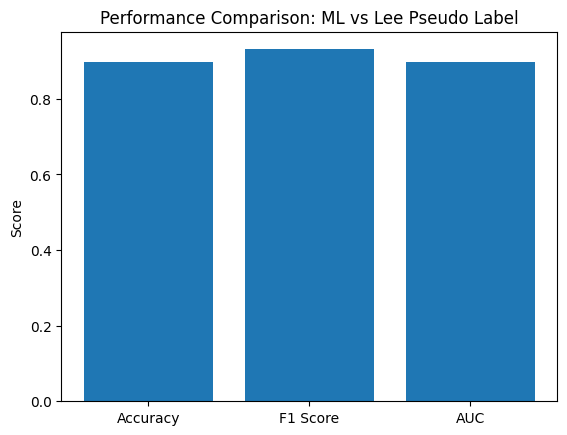


Dataset hasil tersimpan: dataset_pseudo_label_comparison.csv
Grafik tersimpan:
ml_latent_distribution.png
roc_comparison_ml_vs_lee.png
method_comparison.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# ===============================
# LOAD DATASET
# ===============================

df = pd.read_csv("dataset_25000.csv")

features = [
    "Unit_Price",
    "Quantity",
    "Discount",
    "Total_Price"
]

X = df[features]


# ===============================
# LATENT SPACE TRANSFORMATION
# ===============================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=1)
eta_hat = pca.fit_transform(X_scaled)
eta_hat = eta_hat.flatten()

df["latent_score"] = eta_hat


# ======================================================
# MODIFIED MAXIMUM LIKELIHOOD (METODE USULAN)
# ======================================================

median = np.median(eta_hat)

group0 = eta_hat[eta_hat <= median]
group1 = eta_hat[eta_hat > median]

mu0 = np.mean(group0)
mu1 = np.mean(group1)

sigma0 = np.var(group0)
sigma1 = np.var(group1)

pi0 = len(group0)/len(eta_hat)
pi1 = len(group1)/len(eta_hat)

print("\n===== PARAMETER DISTRIBUSI ML =====")
print("mu0 :",mu0)
print("mu1 :",mu1)
print("sigma0 :",sigma0)
print("sigma1 :",sigma1)


def gaussian_likelihood(x, mu, sigma):

    return (1 / np.sqrt(2*np.pi*sigma)) * \
           np.exp(-(x-mu)**2 / (2*sigma))


def likelihood_ratio(x):

    p1 = gaussian_likelihood(x, mu1, sigma1)
    p0 = gaussian_likelihood(x, mu0, sigma0)

    return np.log(p1/p0) - np.log(pi0/pi1)


# =========================================
# QUADRATIC DECISION FUNCTION
# =========================================

A = 1/(2*sigma0) - 1/(2*sigma1)

B = mu1/(sigma1) - mu0/(sigma0)

C = np.log(np.sqrt(sigma0)/np.sqrt(sigma1)) \
    + (mu0**2)/(2*sigma0) \
    - (mu1**2)/(2*sigma1) \
    - np.log(pi0/pi1)


# =========================================
# ADAPTIVE THRESHOLD
# =========================================

if abs(A) < 1e-10:

    c = -C / B

else:

    disc = B**2 - 4*A*C
    c1 = (-B + np.sqrt(disc))/(2*A)
    c2 = (-B - np.sqrt(disc))/(2*A)

    c = np.mean([c1,c2])

print("Threshold adaptif ML:", c)


# =========================================
# GENERATE PSEUDO LABEL ML
# =========================================

pseudo_ml = []

for eta in eta_hat:

    if eta > c:
        pseudo_ml.append(1)
    else:
        pseudo_ml.append(0)

df["pseudo_ml"] = pseudo_ml


# ======================================================
# METODE LEE PSEUDO LABEL (2013)
# ======================================================

labeled_size = 2000

labeled_index = np.random.choice(len(df), labeled_size, replace=False)

Dl = df.iloc[labeled_index]
Du = df.drop(labeled_index)

X_l = Dl[features]
y_l = Dl["pseudo_ml"]

model = LogisticRegression()

model.fit(X_l, y_l)

prob = model.predict_proba(Du[features])

pseudo_lee = np.argmax(prob, axis=1)

Du["pseudo_lee"] = pseudo_lee

df["pseudo_lee"] = 0
df.loc[Du.index, "pseudo_lee"] = pseudo_lee


# ======================================================
# EVALUASI PERBANDINGAN
# ======================================================

y_true = df["pseudo_ml"]
y_pred = df["pseudo_lee"]

accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred)

print("\n===== HASIL METODE LEE =====")
print("Accuracy :", accuracy)
print("F1 Score :", f1)
print("AUC :", auc)

print("\nConfusion Matrix")
print(cm)


# ======================================================
# GRAFIK DISTRIBUSI LATENT SCORE
# ======================================================

plt.figure(figsize=(8,5))

plt.hist(df[df["pseudo_ml"]==0]["latent_score"], bins=40, alpha=0.5, label="ML Class 0")
plt.hist(df[df["pseudo_ml"]==1]["latent_score"], bins=40, alpha=0.5, label="ML Class 1")

plt.axvline(c, color="red", linestyle="--", label="ML Threshold")

plt.xlabel("Latent Score")
plt.ylabel("Frequency")

plt.title("Distribution of Latent Score with ML Adaptive Threshold")

plt.legend()

plt.savefig("ml_latent_distribution.png", dpi=300)

plt.show()


# ======================================================
# ROC CURVE
# ======================================================

fpr, tpr, _ = roc_curve(y_true, y_pred)

plt.figure()

plt.plot(fpr, tpr, label="Lee vs ML (AUC="+str(round(auc,3))+")")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.savefig("roc_comparison_ml_vs_lee.png", dpi=300)

plt.show()


# ======================================================
# BAR CHART PERBANDINGAN
# ======================================================

metrics = ["Accuracy","F1 Score","AUC"]
values = [accuracy, f1, auc]

plt.figure()

plt.bar(metrics, values)

plt.title("Performance Comparison: ML vs Lee Pseudo Label")

plt.ylabel("Score")

plt.savefig("method_comparison.png", dpi=300)

plt.show()


# ======================================================
# SIMPAN DATASET HASIL
# ======================================================

df.to_csv("dataset_pseudo_label_comparison.csv", index=False)

print("\nDataset hasil tersimpan: dataset_pseudo_label_comparison.csv")
print("Grafik tersimpan:")
print("ml_latent_distribution.png")
print("roc_comparison_ml_vs_lee.png")
print("method_comparison.png")

**silhouette_score ML dan Lee**

In [ ]:
from sklearn.metrics import silhouette_score

# evaluasi kualitas cluster pseudo label
sil_ml = silhouette_score(df[["latent_score"]], df["pseudo_ml"])

sil_lee = silhouette_score(df[["latent_score"]], df["pseudo_lee"])

print("Silhouette Score ML :", sil_ml)
print("Silhouette Score Lee :", sil_lee)

Silhouette Score ML : -0.004984239906538394
Silhouette Score Lee : -0.0025274234572455296


/tmp/ipykernel_156/983385822.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Dl["label_init"] = (Dl["latent_score"] > median).astype(int)



===== DISTRIBUSI PSEUDO LABEL LEE =====
pseudo_label_lee
0    14797
1    10203
Name: count, dtype: int64


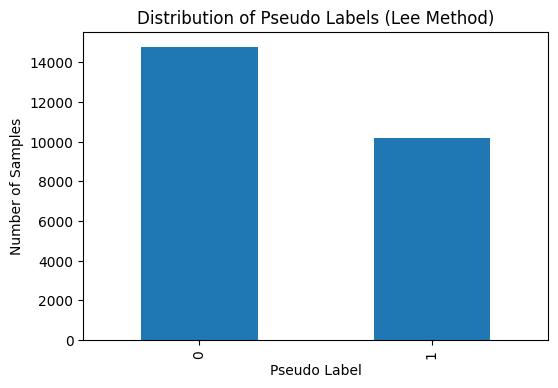

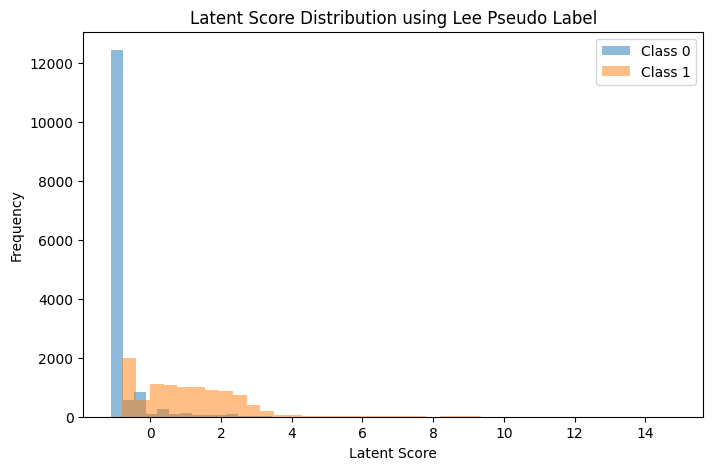


Dataset disimpan: dataset_pseudo_label_lee.csv
Grafik disimpan:
lee_pseudo_label_distribution.png
lee_latent_distribution.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# ===============================
# LOAD DATASET
# ===============================

df = pd.read_csv("dataset_25000.csv")

features = [
    "Unit_Price",
    "Quantity",
    "Discount",
    "Total_Price"
]

X = df[features]

# ===============================
# TRANSFORMASI LATENT SPACE
# ===============================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=1)

latent = pca.fit_transform(X_scaled)

latent = latent.flatten()

df["latent_score"] = latent


# ===============================
# SPLIT DATA (SIMULASI DATA BERLABEL)
# ===============================

labeled_size = 2000

labeled_index = np.random.choice(len(df), labeled_size, replace=False)

Dl = df.iloc[labeled_index]

Du = df.drop(labeled_index)


# ===============================
# LABEL AWAL (DUMMY LABEL)
# ===============================

median = np.median(Dl["latent_score"])

Dl["label_init"] = (Dl["latent_score"] > median).astype(int)

X_l = Dl[features]

y_l = Dl["label_init"]


# ===============================
# TRAIN MODEL (LEE METHOD)
# ===============================

model = LogisticRegression()

model.fit(X_l, y_l)


# ===============================
# GENERATE PSEUDO LABEL
# ===============================

prob = model.predict_proba(Du[features])

pseudo_lee = np.argmax(prob, axis=1)

Du["pseudo_label_lee"] = pseudo_lee

df["pseudo_label_lee"] = 0

df.loc[Du.index, "pseudo_label_lee"] = pseudo_lee


# ===============================
# DISTRIBUSI LABEL
# ===============================

print("\n===== DISTRIBUSI PSEUDO LABEL LEE =====")

label_counts = df["pseudo_label_lee"].value_counts()

print(label_counts)


# ===============================
# GRAFIK DISTRIBUSI LABEL
# ===============================

plt.figure(figsize=(6,4))

label_counts.plot(kind="bar")

plt.title("Distribution of Pseudo Labels (Lee Method)")

plt.xlabel("Pseudo Label")

plt.ylabel("Number of Samples")

plt.savefig("lee_pseudo_label_distribution.png", dpi=300)

plt.show()


# ===============================
# HISTOGRAM LATENT SCORE
# ===============================

plt.figure(figsize=(8,5))

plt.hist(df[df["pseudo_label_lee"]==0]["latent_score"],
         bins=40,
         alpha=0.5,
         label="Class 0")

plt.hist(df[df["pseudo_label_lee"]==1]["latent_score"],
         bins=40,
         alpha=0.5,
         label="Class 1")

plt.title("Latent Score Distribution using Lee Pseudo Label")

plt.xlabel("Latent Score")

plt.ylabel("Frequency")

plt.legend()

plt.savefig("lee_latent_distribution.png", dpi=300)

plt.show()


# ===============================
# SIMPAN DATASET
# ===============================

df.to_csv("dataset_pseudo_label_lee.csv", index=False)

print("\nDataset disimpan: dataset_pseudo_label_lee.csv")

print("Grafik disimpan:")
print("lee_pseudo_label_distribution.png")
print("lee_latent_distribution.png")